# BMWP Fuzzy Model - Spearman Validation

This notebook compares the **real BMWP** values per sampling station against the values **predicted by the fuzzy logic model** (notebook 01a), using Spearman's rank correlation as an external validation of the fuzzy predictions.

## Data Loading

Real vs fuzzy-predicted BMWP per station (transcribed from the fuzzy model run).

In [1]:
import pandas as pd

data = {
    "BMWP": [116, 96, 94, 93, 90, 85, 75, 72, 65, 52, 37, 28, 20, 13],
    "Prediction": [95.81, 87.33, 87.33, 87.33, 87.33, 87.33, 95.81, 87.33,
                   87.33, 52.33, 52.33, 28.67, 28.67, 5.00],
    "Station": ["RA1 (1)", "RA1 (2)", "RC1 (1)", "RC1 (2)", "RF3 (1)", "RA2 (2)",
                "RC2 (2)", "RA2 (1)", "RF2 (2)", "RF2 (1)", "RF3 (2)", "RA3 (1)",
                "RC4 (1)", "RC4 (2)"],
}
df = pd.DataFrame(data)
print(df)

    BMWP  Prediction  Station
0    116       95.81  RA1 (1)
1     96       87.33  RA1 (2)
2     94       87.33  RC1 (1)
3     93       87.33  RC1 (2)
4     90       87.33  RF3 (1)
5     85       87.33  RA2 (2)
6     75       95.81  RC2 (2)
7     72       87.33  RA2 (1)
8     65       87.33  RF2 (2)
9     52       52.33  RF2 (1)
10    37       52.33  RF3 (2)
11    28       28.67  RA3 (1)
12    20       28.67  RC4 (1)
13    13        5.00  RC4 (2)


## Evaluation & Visualisation

Spearman correlation between real and predicted BMWP, with the BMWP/Col quality bands drawn as a coloured background.

## Context: in-sample vs LOOCV Spearman correlation

This notebook originally computed Spearman correlation between observed
BMWP values and predictions from the original fuzzy logic system
(rs = 0.827, p = 0.000265, n = 14). This result reflects in-sample
performance — the fuzzy rules were derived from the same 14 observations
used for this comparison.

For comparison, the redesigned fuzzy system (Approach E: FCM + 3 predictors,
LOOCV) yields a genuinely independent estimate over the folds that produced
an output (see `01f_fuzzy_final.ipynb`). Both results are reported and plotted
side by side below for transparency.

*Modified 2026-06-23 — added LOOCV comparison; supports article Results/Discussion.*

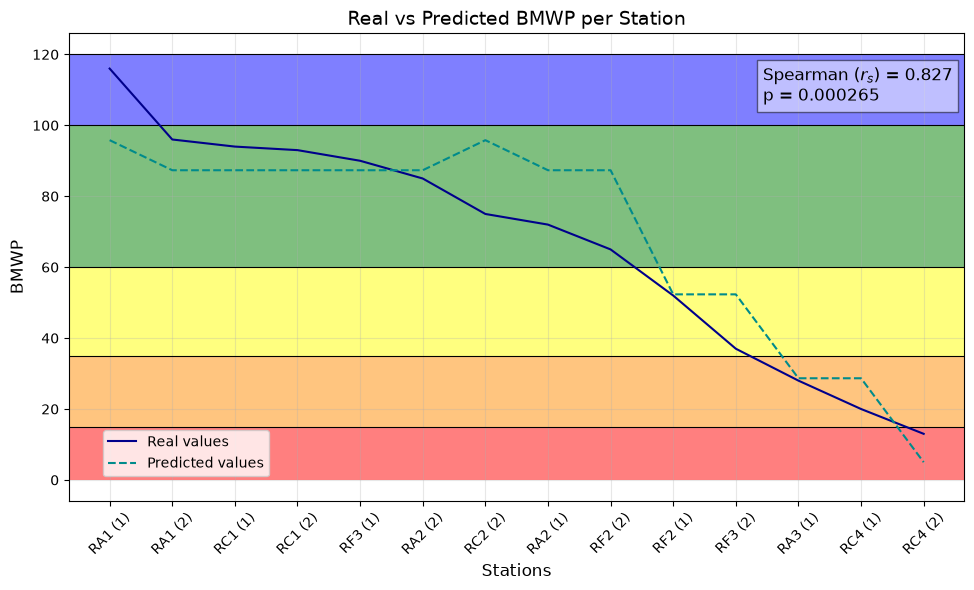

Spearman coefficient: 0.8269015865060567
p-value: 0.0002645214177034014


In [2]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

spearman_corr, p_value = spearmanr(df["BMWP"], df["Prediction"])

plt.figure(figsize=(10, 6))

# Background bands following the BMWP/Col quality classes
colors = ['red', 'darkorange', 'yellow', 'green', 'blue']
ranges = [15, 35, 60, 100]
for i in range(len(ranges) + 1):
    if i == 0:
        plt.axhspan(0, ranges[i], facecolor=colors[i], alpha=0.5)
        plt.axhline(y=ranges[i], color='black', linewidth=0.8)
    elif i == len(ranges):
        plt.axhspan(ranges[i-1], 120, facecolor=colors[i], alpha=0.5)
        plt.axhline(y=120, color='black', linewidth=0.8)
    else:
        plt.axhspan(ranges[i-1], ranges[i], facecolor=colors[i], alpha=0.5)
        plt.axhline(y=ranges[i], color='black', linewidth=0.8)

plt.plot(df["Station"], df["BMWP"], label="Real values", color="darkblue", linestyle="-")
plt.plot(df["Station"], df["Prediction"], label="Predicted values", color="darkcyan", linestyle="--")

plt.xlabel("Stations", fontsize=12)
plt.ylabel("BMWP", fontsize=12)
plt.title("Real vs Predicted BMWP per Station", fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0.03, 0.1675))
plt.grid(True, alpha=0.3)

plt.text(
    0.775, 0.93,
    f"Spearman ($r_s$) = {round(spearman_corr, 3)}\n"
    f"p = {round(p_value, 6)}",
    transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.5)
)

plt.tight_layout()
plt.savefig("../../figures/bmwp_spearman.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Spearman coefficient: {spearman_corr}")
print(f"p-value: {p_value}")

## Side-by-side comparison: in-sample vs LOOCV Spearman

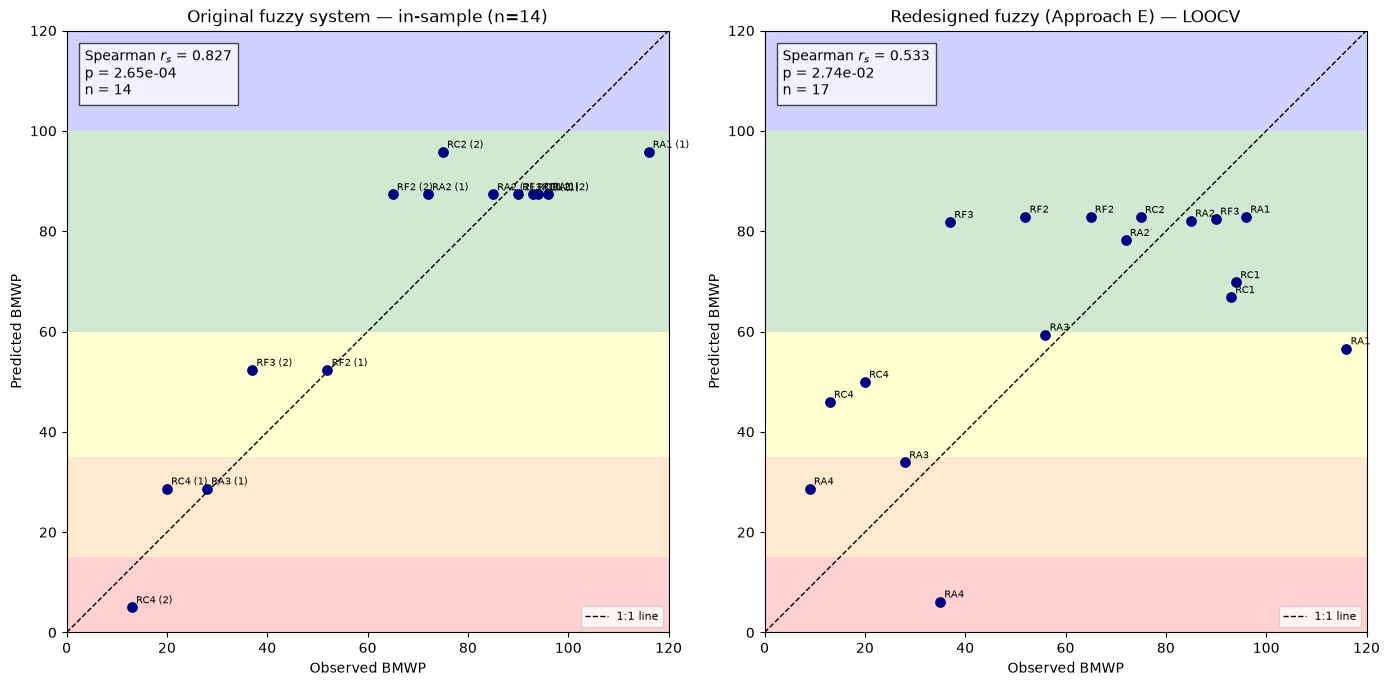

In-sample (n=14):  rs = 0.827, p = 0.000264521
LOOCV    (n=17): rs = 0.533, p = 0.0274483


In [3]:
# Side-by-side Spearman comparison: original in-sample (n=14) vs redesigned LOOCV.
# The redesigned per-fold predictions are produced by 01f_fuzzy_final.ipynb.
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

loocv = pd.read_csv("../../outputs/fuzzy_final_bmwp_loocv_predictions.csv")

rs_in, p_in = spearmanr(df["BMWP"], df["Prediction"])
rs_lo, p_lo = spearmanr(loocv["Observed_BMWP"], loocv["Predicted_BMWP"])

bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]

def panel(ax, obs, pred, labels, rs, pval, n, title):
    for lo, hi, col in bands:                 # BMWP/Col quality bands (on predicted axis)
        ax.axhspan(lo, hi, facecolor=col, alpha=0.18)
    ax.plot([0, 120], [0, 120], 'k--', lw=1, label='1:1 line')   # 1:1 reference
    ax.scatter(obs, pred, color='navy', s=45, zorder=3)
    for x, y, lab in zip(obs, pred, labels):
        ax.annotate(str(lab), (x, y), fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax.set_xlim(0, 120); ax.set_ylim(0, 120); ax.set_aspect('equal')
    ax.set_xlabel("Observed BMWP"); ax.set_ylabel("Predicted BMWP")
    ax.set_title(title)
    ax.text(0.03, 0.97, f"Spearman $r_s$ = {rs:.3f}\np = {pval:.2e}\nn = {n}",
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))
    ax.legend(loc='lower right', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
panel(axes[0], df["BMWP"], df["Prediction"], df["Station"], rs_in, p_in, len(df),
      "Original fuzzy system — in-sample (n=14)")
panel(axes[1], loocv["Observed_BMWP"], loocv["Predicted_BMWP"], loocv["Station"],
      rs_lo, p_lo, len(loocv), "Redesigned fuzzy (Approach E) — LOOCV")
plt.tight_layout()
plt.savefig("../../figures/bmwp_spearman_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"In-sample (n={len(df)}):  rs = {rs_in:.3f}, p = {p_in:.6g}")
print(f"LOOCV    (n={len(loocv)}): rs = {rs_lo:.3f}, p = {p_lo:.6g}")